In [1]:
# Load Dataset
# ==========================================


from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv("Real_Estate.csv")

print(df.head())
print(df.shape)

Saving Real_Estate.csv to Real_Estate.csv
             Transaction date  House age  Distance to the nearest MRT station  \
0  2012-09-02 16:42:30.519336       13.3                            4082.0150   
1  2012-09-04 22:52:29.919544       35.5                             274.0144   
2  2012-09-05 01:10:52.349449        1.1                            1978.6710   
3  2012-09-05 13:26:01.189083       22.2                            1055.0670   
4  2012-09-06 08:29:47.910523        8.5                             967.4000   

   Number of convenience stores   Latitude   Longitude  \
0                             8  25.007059  121.561694   
1                             2  25.012148  121.546990   
2                            10  25.003850  121.528336   
3                             5  24.962887  121.482178   
4                             6  25.011037  121.479946   

   House price of unit area  
0                  6.488673  
1                 24.970725  
2                 26.694267  
3 


Linear Regression
MAE : 9.556
RMSE: 11.218
R²  : 0.545

Decision Tree
MAE : 13.669
RMSE: 16.522
R²  : 0.013

Random Forest
MAE : 10.082
RMSE: 11.869
R²  : 0.491

Model Comparison
               Model        MAE       RMSE  R2 Score
0  Linear Regression   9.555609  11.217548  0.545140
1      Decision Tree  13.669486  16.522417  0.013201
2      Random Forest  10.082294  11.869127  0.490764


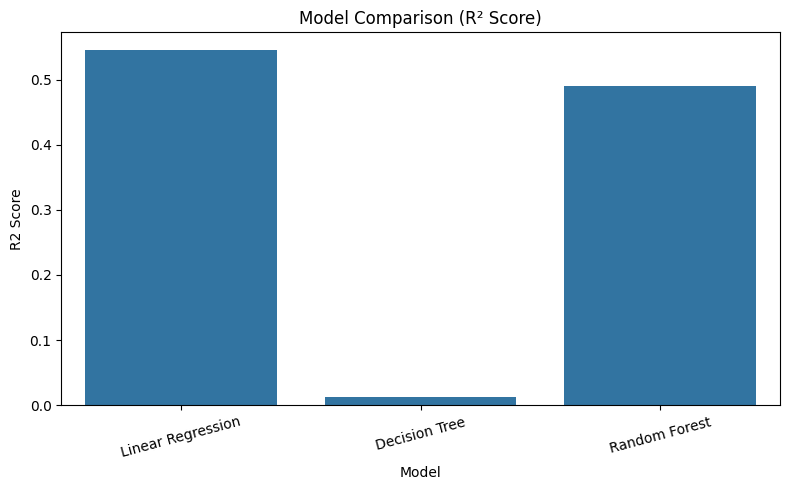


Best Model: Linear Regression


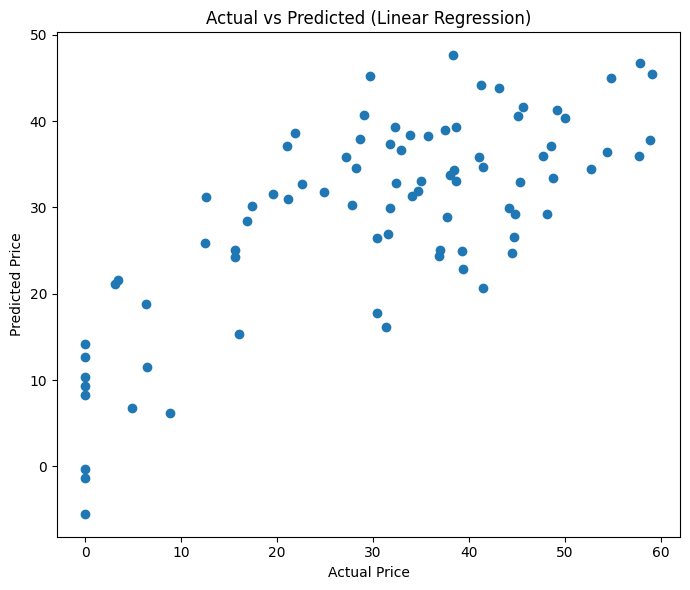


Best model saved as:
best_house_price_model.pkl

All images saved inside:
Result_Images


In [2]:
# ==========================================
# HOUSE PRICE PREDICTION - REAL ESTATE DATA
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import os

# ==========================================
# Create Folder to Save Images
# ==========================================
save_folder = "Result_Images"
os.makedirs(save_folder, exist_ok=True)

# ==========================================


# ==========================================
# Data Preprocessing
# ==========================================

# Convert transaction date to numerical value
df['Transaction date'] = pd.to_datetime(df['Transaction date'])
df['Transaction date'] = df['Transaction date'].map(pd.Timestamp.toordinal)

# Features and Target
X = df.drop('House price of unit area', axis=1)
y = df['House price of unit area']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# Models
# ==========================================
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

results = []

# ==========================================
# Training and Evaluation
# ==========================================
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

    print("\n", "="*40)
    print(name)
    print("="*40)
    print("MAE :", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R²  :", round(r2, 3))

# ==========================================
# Results Table
# ==========================================
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

print("\nModel Comparison")
print(results_df)

# Save Results CSV
results_df.to_csv("model_results.csv", index=False)

# ==========================================
# Model Comparison Plot
# ==========================================
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="R2 Score",
    data=results_df
)

plt.title("Model Comparison (R² Score)")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    os.path.join(save_folder, "Model_Comparison.png")
)

plt.show()

# ==========================================
# Best Model
# ==========================================
best_model_name = results_df.sort_values(
    by="R2 Score",
    ascending=False
).iloc[0]["Model"]

print("\nBest Model:", best_model_name)

best_model = models[best_model_name]

# ==========================================
# Actual vs Predicted Plot
# ==========================================
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_best)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted ({best_model_name})")

plt.tight_layout()

plt.savefig(
    os.path.join(save_folder,
                 "Actual_vs_Predicted.png")
)

plt.show()

# ==========================================
# Feature Importance
# (Only for Tree-Based Models)
# ==========================================
if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(8,5))
    sns.barplot(
        x="Importance",
        y="Feature",
        data=importance
    )

    plt.title("Feature Importance")
    plt.tight_layout()

    plt.savefig(
        os.path.join(save_folder,
                     "Feature_Importance.png")
    )

    plt.show()

# ==========================================
# Save Best Model
# ==========================================
import joblib

joblib.dump(best_model, "best_house_price_model.pkl")

print("\nBest model saved as:")
print("best_house_price_model.pkl")

print("\nAll images saved inside:")
print(save_folder)